In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [20]:
class PinholeCamera():
    def __init__(self, K : np.ndarray ,dist_coefs : np.ndarray, world_R_cam : np.ndarray  , world_t_cam : np.ndarray ):
        self.K = K
        self.dist_coefs = dist_coefs
        self.world_R_cam = world_R_cam
        self.world_t_cam = world_t_cam
        self.world_T_cam = np.eye(4)
        self.world_T_cam[:3, :3] = world_R_cam
        self.world_T_cam[:3, 3] = world_t_cam.flatten()

    def project(self, world_pts_3d: np.ndarray) -> np.ndarray:
        n = world_pts_3d.shape[0]
        pts_homo = np.hstack((world_pts_3d, np.ones((n, 1))))
        cam_T_world = np.linalg.inv(self.world_T_cam)
        pts_cam = (cam_T_world @ pts_homo.T).T

        z = pts_cam[:, 2:3]
        z[z<=0] = 1e-6
        pts_2d_norm = pts_cam[:, :2] / z

        x = pts_2d_norm[:, 0]
        y = pts_2d_norm[:, 1]
        r2 = x**2 + y**2
        k1, k2, p1, p2, k3 = self.dist_coefs

        radial = (1 + k1*r2 + k2*r2**2 + k3*r2**3)
        x_dist = x * radial + (2*p1*x*y + p2*(r2 + 2*x**2))
        y_dist = y * radial + (p1*(r2 + 2*y**2) + 2*p2*x*y)

        pts_dist_homo = np.stack((x_dist, y_dist, np.ones_like(x_dist)), axis=1)
        pixels = (self.K @ pts_dist_homo.T).T
        return pixels[:, :2]

    def unproject(self, image_pts_2d: np.ndarray) -> np.ndarray:
        n = image_pts_2d.shape[0]
        pixels_homo = np.hstack((image_pts_2d, np.ones((n, 1))))
        K_inv = np.linalg.inv(self.K)
        pts_dist = (K_inv @ pixels_homo.T).T

        x_d = pts_dist[:, 0]
        y_d = pts_dist[:, 1]
        x, y = x_d, y_d
        k1, k2, p1, p2, k3 = self.dist_coefs

        for _ in range(5):
            r2 = x**2 + y**2
            radial = (1 + k1*r2 + k2*r2**2 + k3*r2**3)
            dx = 2*p1*x*y + p2*(r2 + 2*x**2)
            dy = p1*(r2 + 2*y**2) + 2*p2*x*y
            x = (x_d - dx) / radial
            y = (y_d - dy) / radial

        rays_cam = np.stack((x, y, np.ones_like(x)), axis=1)
        rays_world = (self.world_R_cam @ rays_cam.T).T
        return rays_world / np.linalg.norm(rays_world, axis=1, keepdims=True)

In [21]:
class StereoEstimator:
    def __init__(self, cam1, cam2, pts1, pts2):
        self.cam1 = cam1
        self.cam2 = cam2
        self.pts1 = pts1
        self.pts2 = pts2

    def triangulate_rays(self):
        rays1 = self.cam1.unproject(self.pts1)
        rays2 = self.cam2.unproject(self.pts2)

        origin1 = self.cam1.world_t_cam.flatten()
        origin2 = self.cam2.world_t_cam.flatten()

        baseline = origin1-origin2

        # ALGORITMO PARA RETAS REVERSAS (INTERCESSÃO DOS RAIOS)
        a = np.sum(rays1 * rays1, axis=1)
        b = np.sum(rays1 * rays2, axis=1)
        c = np.sum(rays2 * rays2, axis=1)
        d = np.sum(rays1 * baseline, axis=1)
        e = np.sum(rays2 * baseline, axis=1)

        # Denominador do sistema
        D = (a * c) - (b * b)

        # Prevenindo divisão por zero (caso raios sejam perfeitamente paralelos)
        D = np.where(D < 1e-8, 1e-8, D)

        # 4. Encontrar os escalares (distâncias ao longo do raio)
        t1 = (b * e - c * d) / D
        t2 = (a * e - b * d) / D

        # 5. Encontrar os pontos de maior aproximação em cada reta
        P1 = origin1 + t1[:, np.newaxis] * rays1
        P2 = origin2 + t2[:, np.newaxis] * rays2

        # 6. O ponto 3D estimado é o ponto médio entre P1 e P2
        pts3d_estimated = (P1 + P2) / 2.0

        return pts3d_estimated

    def _get_projection_matrix(self, cam):
        K = cam.K
        Rt = np.linalg.inv(cam.world_T_cam)
        Rt = Rt[:3,:]
        P = K @ Rt
        return P

    def triangulate_cv2(self):
        P1 = self._get_projection_matrix(self.cam1)
        P2 = self._get_projection_matrix(self.cam2)
        pts3dh = cv2.triangulatePoints(P1, P2, self.pts1.T, self.pts2.T)

        pts3d_norm = pts3dh[:3, :] / pts3dh[3, :]

        return pts3d_norm.T

Mean Error (Beam Geometry): 0.0000000000 m
Mean Error (OpenCV - Projection Matrix)   : 0.0000000000 m



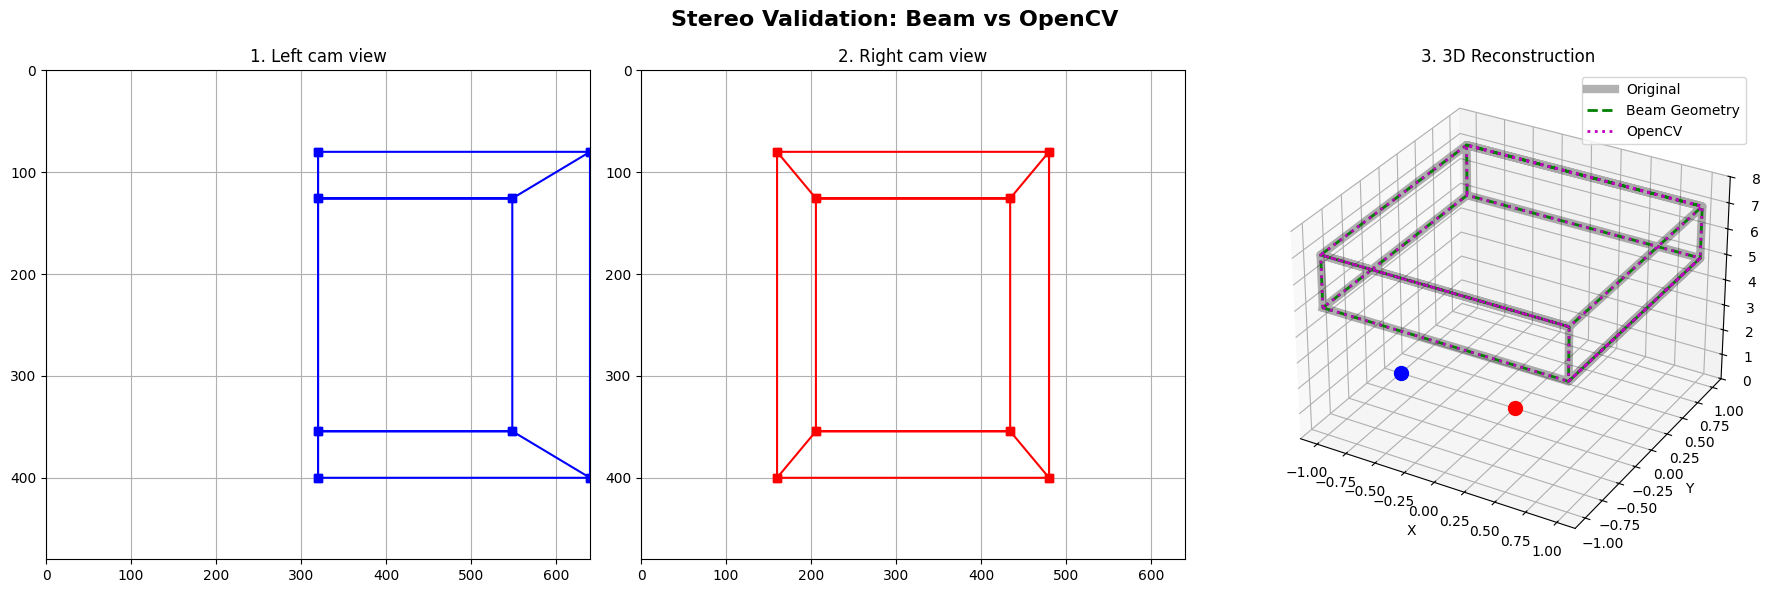

In [24]:
# ==========================================
# Case tests - AI Generated
# ==========================================
def test_stereo():
    K = np.array([[800, 0, 320], [0, 800, 240], [0, 0, 1]])
    dist = np.zeros(5)
    R = np.eye(3)

    cam1_pos = np.array([-1.0, 0, 0]) # Esquerda
    cam2_pos = np.array([0, 0, 0])  # Direita

    cam_left = PinholeCamera(K, dist, R, cam1_pos)
    cam_right = PinholeCamera(K, dist, R, cam2_pos)

    obj_3d = np.array([
        [-1,-1,5], [1,-1,5], [1,1,5], [-1,1,5], [-1,-1,5],
        [-1,-1,7], [1,-1,7], [1,1,7], [-1,1,7], [-1,-1,7],
        [1,-1,7], [1,-1,5], [1,1,5], [1,1,7], [-1,1,7], [-1,1,5]
    ])

    pts1 = cam_left.project(obj_3d)
    pts2 = cam_right.project(obj_3d)

    estimator = StereoEstimator(cam_left, cam_right, pts1, pts2)

    rec_rays = estimator.triangulate_rays()
    rec_cv2 = estimator.triangulate_cv2()

    erro_rays = np.mean(np.linalg.norm(obj_3d - rec_rays, axis=1))
    erro_cv2 = np.mean(np.linalg.norm(obj_3d - rec_cv2, axis=1))

    print(f"Mean Error (Beam Geometry): {erro_rays:.10f} m")
    print(f"Mean Error (OpenCV - Projection Matrix)   : {erro_cv2:.10f} m\n")

    fig = plt.figure(figsize=(18, 6))
    fig.suptitle("Stereo Validation: Beam vs OpenCV", fontsize=16, fontweight='bold')

    ax1 = fig.add_subplot(131)
    ax1.plot(pts1[:,0], pts1[:,1], 'b-s')
    ax1.set_xlim(0, 640); ax1.set_ylim(480, 0)
    ax1.set_title("1. Left cam view")
    ax1.grid(True)

    ax2 = fig.add_subplot(132)
    ax2.plot(pts2[:,0], pts2[:,1], 'r-s')
    ax2.set_xlim(0, 640); ax2.set_ylim(480, 0)
    ax2.set_title("2. Right cam view")
    ax2.grid(True)

    ax3 = fig.add_subplot(133, projection='3d')
    ax3.plot(obj_3d[:,0], obj_3d[:,1], obj_3d[:,2], 'k-', alpha=0.3, linewidth=6, label='Original')
    ax3.plot(rec_rays[:,0], rec_rays[:,1], rec_rays[:,2], 'g--', linewidth=2, label='Beam Geometry')
    ax3.plot(rec_cv2[:,0], rec_cv2[:,1], rec_cv2[:,2], 'm:', linewidth=2, label='OpenCV')

    ax3.scatter(*cam1_pos, color='b', s=100)
    ax3.scatter(*cam2_pos, color='r', s=100)

    ax3.set_title("3. 3D Reconstruction")
    ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')
    ax3.set_zlim(0, 8)
    ax3.legend()

    plt.tight_layout()
    plt.show()

test_stereo()